# 4. Feature Engineering

### Weather data

Calculate monthly averages per region (mean of all Jans, Febs, etc.), number of heatwave days, drought index, 

Load weather data parquet

In [1]:
import pandas as pd

In [2]:
weather = pd.read_parquet('../Data/Processed/weather_states.parquet')
weather.sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state
31260,2024-07-25 00:00:00+00:00,17.725002,22.600000,12.500000,0.2,10.739833,Sachsen
119355,2007-09-08 00:00:00+00:00,13.614082,16.261999,10.962000,0.8,16.489416,Hessen
83032,2015-10-08 00:00:00+00:00,13.398335,15.452500,12.002501,4.7,8.209263,Hamburg
100533,2020-09-02 00:00:00+00:00,14.443748,19.400000,8.500000,0.1,9.793059,Niedersachsen
27986,2015-08-08 00:00:00+00:00,27.233332,32.475002,23.175001,0.0,21.485697,Sachsen
28622,2017-05-05 00:00:00+00:00,8.604166,10.750000,7.100000,1.5,11.200571,Sachsen
122827,2017-03-11 00:00:00+00:00,5.589001,10.939000,1.639000,0.0,11.480557,Hessen
26844,2012-06-22 00:00:00+00:00,18.160416,21.925001,14.325000,0.0,18.806337,Sachsen
52780,2018-12-19 00:00:00+00:00,2.097917,4.150000,0.150000,1.0,16.489416,Sachsen-Anhalt
7072,2022-11-10 00:00:00+00:00,11.433333,14.200000,9.200000,0.0,24.344624,Bremen


In [3]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125680 entries, 0 to 125679
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype              
---  ------               --------------   -----              
 0   date                 125680 non-null  datetime64[ms, UTC]
 1   temperature_2m_mean  125680 non-null  float32            
 2   temperature_2m_max   125680 non-null  float32            
 3   temperature_2m_min   125680 non-null  float32            
 4   precipitation_sum    125680 non-null  float32            
 5   wind_speed_10m_max   125680 non-null  float32            
 6   state                125680 non-null  object             
dtypes: datetime64[ms, UTC](1), float32(5), object(1)
memory usage: 4.3+ MB


In [4]:
# Extract month and year from datetime

weather['month'] = weather['date'].dt.month
weather['year'] = weather['date'].dt.year
weather['monthyear'] = weather['month'].astype(str) + '_' + weather['year'].astype(str)
weather.sample(5)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear
11212,2012-09-08 00:00:00+00:00,17.210417,22.450001,12.000000,0.0,9.387651,Nordrhein-Westfalen,9,2012,9_2012
54742,2024-05-03 00:00:00+00:00,16.747917,20.500000,13.150000,0.9,16.746773,Sachsen-Anhalt,5,2024,5_2024
69083,2020-08-03 00:00:00+00:00,18.989582,23.250000,15.350000,0.2,16.039202,Berlin,8,2020,8_2020
55567,2005-02-02 00:00:00+00:00,1.218333,2.672500,-0.927500,5.2,20.018072,Thüringen,2,2005,2_2005
79350,2005-09-08 00:00:00+00:00,21.112917,26.352501,15.752501,0.0,17.884428,Hamburg,9,2005,9_2005


In [5]:
monthly = weather.groupby(['state', 'year', 'month']).agg(
    temp_mean = ('temperature_2m_mean', 'mean'),
    precip_sum = ('precipitation_sum', 'sum')
).reset_index()

monthly

,state,year,month,temp_mean,precip_sum
0,Baden-Württemberg,2003,7,19.441086,56.400002
1,Baden-Württemberg,2003,8,23.156878,18.400000
2,Baden-Württemberg,2003,9,14.583459,25.699999
3,Baden-Württemberg,2003,10,6.437322,91.799995
4,Baden-Württemberg,2003,11,5.571653,58.000000
...,...,...,...,...,...
4123,Thüringen,2024,8,19.984138,72.899994
4124,Thüringen,2024,9,15.468820,88.400002
4125,Thüringen,2024,10,11.061694,62.299999
4126,Thüringen,2024,11,4.483958,53.499996


In [6]:
# Compute baseline temperature and precipitation (long-term monthly mean per Bundesland)
baseline = monthly.groupby(['state', 'month']).agg(
    baseline_temp = ('temp_mean', 'mean'),
    baseline_precip = ('precip_sum', 'mean')
).reset_index()

baseline


,state,month,baseline_temp,baseline_precip
0,Baden-Württemberg,1,0.888582,73.585716
1,Baden-Württemberg,2,1.658827,58.023811
2,Baden-Württemberg,3,4.780743,60.757145
3,Baden-Württemberg,4,9.264582,61.628571
4,Baden-Württemberg,5,13.113695,91.942856
...,...,...,...,...
187,Thüringen,8,18.361685,84.522728
188,Thüringen,9,14.538055,62.849998
189,Thüringen,10,10.015421,59.663635
190,Thüringen,11,5.154050,56.386364


In [7]:
# Calculate flood risk as n days per month with heavy rain based on regional thresholds
# NB - threshold for heavy rain can differ between regions 
# (some regions may have ecological features better able to deal with more rain)

thresholds = weather.groupby(['state','month'])['precipitation_sum'].quantile(0.95).reset_index()
thresholds = thresholds.rename(columns={'precipitation_sum':'rain_thresh'})

weather = weather.merge(thresholds, on=['state','month'])

weather['heavy_rain'] = (weather['precipitation_sum'] > 
                                     weather['rain_thresh']).astype(int)

weather.sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear,rain_thresh,heavy_rain
81164,2010-08-27 00:00:00+00:00,14.094167,15.102500,12.7025,17.800001,19.770523,Hamburg,8,2010,8_2010,10.295000,1
56270,2007-01-06 00:00:00+00:00,7.718334,8.672500,6.7225,2.000000,22.545315,Thüringen,1,2007,1_2007,7.900000,0
32095,2005-05-06 00:00:00+00:00,9.636084,12.509001,7.4090,7.000000,21.897945,Mecklenburg-Vorpommern,5,2005,5_2005,8.700000,0
28619,2017-05-02 00:00:00+00:00,9.170833,12.150000,6.5500,1.700000,22.972401,Sachsen,5,2017,5_2017,11.150000,0
29254,2019-01-27 00:00:00+00:00,3.083334,5.100000,2.0500,0.400000,22.668570,Sachsen,1,2019,1_2019,10.400001,0
13558,2019-02-10 00:00:00+00:00,6.323834,8.065500,3.2155,20.500004,34.971920,Nordrhein-Westfalen,2,2019,2_2019,10.870000,1
101729,2023-12-12 00:00:00+00:00,6.289583,7.400000,3.5500,2.500000,16.622490,Niedersachsen,12,2023,12_2023,9.594999,0
108485,2020-12-08 00:00:00+00:00,3.312500,5.300000,1.5500,0.000000,12.224107,Schleswig-Holstein,12,2020,12_2020,9.900001,0
107790,2019-01-13 00:00:00+00:00,6.418750,8.150000,4.7000,4.800000,36.941685,Schleswig-Holstein,1,2019,1_2019,10.100000,0
99072,2016-09-02 00:00:00+00:00,18.356750,24.013000,11.6130,0.000000,12.599999,Niedersachsen,9,2016,9_2016,9.100000,0


In [8]:
weather[weather['heavy_rain']==1].sample(10)

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,wind_speed_10m_max,state,month,year,monthyear,rain_thresh,heavy_rain
15106,2023-05-08 00:00:00+00:00,14.380082,19.015499,11.115500,15.800000,16.954432,Nordrhein-Westfalen,5,2023,5_2023,10.300000,1
115146,2017-09-01 00:00:00+00:00,13.206250,14.250000,11.850000,23.200003,11.090103,Bayern,9,2017,9_2017,10.215000,1
40774,2007-08-08 00:00:00+00:00,14.519916,15.634501,13.034500,19.100000,17.873556,Baden-Württemberg,8,2007,8_2007,12.100000,1
8513,2005-04-19 00:00:00+00:00,8.370833,9.300000,7.200000,29.500000,12.979984,Nordrhein-Westfalen,4,2005,4_2005,7.810000,1
9335,2007-07-20 00:00:00+00:00,19.529169,24.650000,16.250000,14.600000,18.057508,Nordrhein-Westfalen,7,2007,7_2007,12.695001,1
24873,2007-01-29 00:00:00+00:00,2.679167,3.475000,1.725000,10.800002,36.179550,Sachsen,1,2007,1_2007,10.400001,1
12597,2016-06-24 00:00:00+00:00,21.210417,24.350000,17.950001,16.800001,10.440001,Nordrhein-Westfalen,6,2016,6_2016,11.365000,1
83429,2016-11-08 00:00:00+00:00,0.310833,1.552500,-2.697500,9.099999,19.694992,Hamburg,11,2016,11_2016,8.905000,1
44323,2017-04-26 00:00:00+00:00,3.550000,6.650000,1.350000,12.600002,9.178235,Baden-Württemberg,4,2017,4_2017,9.855000,1
18820,2012-01-05 00:00:00+00:00,4.802834,6.794500,2.244500,16.400000,36.436550,Rheinland-Pfalz,1,2012,1_2012,8.450001,1


In [9]:
# aggregate mean monthly temp, max monthly temp, precipitation sum per month per Bundesland

weather_monthly = weather.groupby(['state', 'monthyear']).agg(
    year = ('year', 'min'),
    month = ('month', 'min'),
    mean_temp = ('temperature_2m_mean', 'mean'),
    max_temp = ('temperature_2m_max', 'max'),
    total_precip = ('precipitation_sum', 'sum'),
    n_hot_days=('temperature_2m_max', lambda x: (x > 30).sum()),
    heavy_rain_days=('heavy_rain','sum')
).reset_index()

weather_monthly.sample(10)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days
1306,Hamburg,10_2019,2019,10,11.090121,20.700001,105.299995,0,2
2719,Rheinland-Pfalz,4_2014,2014,4,11.268598,20.744499,33.400002,0,2
2338,Nordrhein-Westfalen,10_2019,2019,10,11.339895,22.365499,126.800003,0,3
3686,Schleswig-Holstein,1_2012,2012,1,2.515081,9.467500,91.300003,0,3
1425,Hamburg,4_2010,2010,4,8.203681,22.702499,26.400000,0,0
1012,Brandenburg,9_2005,2005,9,16.270569,27.630499,46.099998,0,2
1293,Hamburg,10_2006,2006,10,12.966815,20.102501,58.600002,0,2
354,Bayern,2_2013,2013,2,-1.696804,5.859000,55.099998,0,3
4029,Thüringen,5_2013,2013,5,11.499113,22.722500,195.300003,0,5
3701,Schleswig-Holstein,2_2006,2006,2,1.181042,6.617500,32.899998,0,0


In [10]:
# Merge baseline back to weather df
weather_monthly = weather_monthly.merge(baseline, on=['state', 'month'])

# Compute anomaly 
# for precip - calculate relative anomaly, e.g. -0.4 = 40% drier than normal
# for temp - stick with original scale (20C is not really "100% hotter" than 10C)
weather_monthly['temp_anomaly'] = (weather_monthly['mean_temp'] - weather_monthly['baseline_temp'])
weather_monthly['precip_prop_anomaly'] = (weather_monthly['total_precip'] - weather_monthly['baseline_precip'])/weather_monthly['baseline_precip']


In [11]:
# Compute drought index as temp anomaly - precip anomaly
# (use z-scores to get temp and precip on same scale)
weather_monthly['temp_anom_z'] = weather_monthly.groupby(['state', 'month'])['temp_anomaly'].transform(
    lambda x: (x - x.mean()) / x.std()
)

weather_monthly['precip_anom_z'] = weather_monthly.groupby(['state', 'month'])['precip_prop_anomaly'].transform(
    lambda x: (x - x.mean()) / x.std()
)

weather_monthly['drought_index'] = weather_monthly['temp_anom_z'] - weather_monthly['precip_anom_z']

weather_monthly.sample(5)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,baseline_precip,temp_anomaly,precip_prop_anomaly,temp_anom_z,precip_anom_z,drought_index
1672,Hessen,3_2020,2020,3,5.496057,15.639000,97.699997,0,2,4.997900,67.838097,0.498157,0.440194,0.278087,0.756175,-0.478087
3382,Sachsen-Anhalt,11_2009,2009,11,8.315930,16.243500,64.200005,0,2,6.184668,45.399998,2.131263,0.414097,1.868688,0.676127,1.192560
3956,Thüringen,1_2024,2024,1,0.725739,10.800000,61.000000,0,2,0.513394,61.400002,0.212345,-0.006515,0.082151,-0.017347,0.099499
2201,Niedersachsen,4_2012,2012,4,8.534320,24.463001,43.099998,0,0,9.605122,42.500000,-1.070802,0.014118,-0.591317,0.031501,-0.622818
1001,Brandenburg,8_2016,2016,8,19.129961,33.430500,22.800001,2,0,19.615812,55.200001,-0.485851,-0.586957,-0.310609,-0.807911,0.497303


Add lagged weather variables (1+2+3 month lag, 3+6 month rolling-mean lag)

In [12]:
# First sort weather_monthly by state, year, month

weather_monthly_sorted = weather_monthly.sort_values(['state', 'year', 'month']).copy()
weather_monthly_sorted.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,baseline_precip,temp_anomaly,precip_prop_anomaly,temp_anom_z,precip_anom_z,drought_index
192,Baden-Württemberg,7_2003,2003,7,19.441086,31.734499,56.400002,2,1,19.108015,80.540909,0.333071,-0.299735,0.218184,-0.621976,0.840159
214,Baden-Württemberg,8_2003,2003,8,23.156878,34.684498,18.400000,12,0,18.709295,79.786362,4.447582,-0.769384,2.221096,-2.022276,4.243373
236,Baden-Württemberg,9_2003,2003,9,14.583459,27.684500,25.699999,0,0,14.722257,57.586365,-0.138798,-0.553714,-0.091014,-1.327952,1.236938
0,Baden-Württemberg,10_2003,2003,10,6.437322,20.734499,91.799995,0,2,10.330837,61.754543,-3.893515,0.486530,-2.139184,1.295548,-3.434732
22,Baden-Württemberg,11_2003,2003,11,5.571653,15.334500,58.000000,0,1,5.168454,64.163643,0.403199,-0.096061,0.284581,-0.176771,0.461352


In [13]:
# 1 month lag
weather_monthly_sorted['temp_anom_z_lag1'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(1)
weather_monthly_sorted['precip_anom_z_lag1'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(1)
weather_monthly_sorted['n_hot_days_lag1'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(1)
weather_monthly_sorted['drought_index_lag1'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(1)
weather_monthly_sorted['heavy_rain_days_lag1'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(1)
# 2 month lag
weather_monthly_sorted['temp_anom_z_lag2'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(2)
weather_monthly_sorted['precip_anom_z_lag2'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(2)
weather_monthly_sorted['n_hot_days_lag2'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(2)
weather_monthly_sorted['drought_index_lag2'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(2)
weather_monthly_sorted['heavy_rain_days_lag2'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(2)
# 3 month lag
weather_monthly_sorted['temp_anom_z_lag3'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].shift(3)
weather_monthly_sorted['precip_anom_z_lag3'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].shift(3)
weather_monthly_sorted['n_hot_days_lag3'] = weather_monthly_sorted.groupby('state')['n_hot_days'].shift(3)
weather_monthly_sorted['drought_index_lag3'] = weather_monthly_sorted.groupby('state')['drought_index'].shift(3)
weather_monthly_sorted['heavy_rain_days_lag3'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].shift(3)



# 3 month rolling mean (shift back one month to avoid including current month in mean)
weather_monthly_sorted['temp_anom_z_roll3'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['precip_anom_z_roll3'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['n_hot_days_roll3'] = weather_monthly_sorted.groupby('state')['n_hot_days'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['drought_index_roll3'] = weather_monthly_sorted.groupby('state')['drought_index'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
weather_monthly_sorted['heavy_rain_days_roll3'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].transform(
    lambda x: x.shift(1).rolling(3).mean()
)
# 6 month rolling mean (shift back one month to avoid including current month in mean)
weather_monthly_sorted['temp_anom_z_roll6'] = weather_monthly_sorted.groupby('state')['temp_anom_z'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['precip_anom_z_roll6'] = weather_monthly_sorted.groupby('state')['precip_anom_z'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['n_hot_days_roll6'] = weather_monthly_sorted.groupby('state')['n_hot_days'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['drought_index_roll6'] = weather_monthly_sorted.groupby('state')['drought_index'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)
weather_monthly_sorted['heavy_rain_days_roll6'] = weather_monthly_sorted.groupby('state')['heavy_rain_days'].transform(
    lambda x: x.shift(1).rolling(6).mean()
)

In [14]:
weather_monthly_sorted.head(5)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll3,precip_anom_z_roll3,n_hot_days_roll3,drought_index_roll3,heavy_rain_days_roll3,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6
192,Baden-Württemberg,7_2003,2003,7,19.441086,31.734499,56.400002,2,1,19.108015,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
214,Baden-Württemberg,8_2003,2003,8,23.156878,34.684498,18.400000,12,0,18.709295,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
236,Baden-Württemberg,9_2003,2003,9,14.583459,27.684500,25.699999,0,0,14.722257,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,Baden-Württemberg,10_2003,2003,10,6.437322,20.734499,91.799995,0,2,10.330837,...,0.782755,-1.324068,4.666667,2.106823,0.333333,NaN,NaN,NaN,NaN,NaN
22,Baden-Württemberg,11_2003,2003,11,5.571653,15.334500,58.000000,0,1,5.168454,...,-0.003034,-0.684893,4.000000,0.681860,0.666667,NaN,NaN,NaN,NaN,NaN


Remove 2003 data (was only used to calculate lagged variables)

In [15]:
weather_monthly_sorted = weather_monthly_sorted.loc[weather_monthly_sorted['year']>2003]
weather_monthly_sorted.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll3,precip_anom_z_roll3,n_hot_days_roll3,drought_index_roll3,heavy_rain_days_roll3,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6
66,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,-0.782721,0.099744,0.0,-0.882465,1.333333,0.000017,-0.612162,2.333333,0.612179,0.833333
87,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,-0.223042,0.216010,0.0,-0.439053,2.000000,-0.113038,-0.234442,2.000000,0.121404,1.333333
108,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,-0.346620,0.042150,0.0,-0.388771,2.333333,-0.497580,-0.013787,0.000000,-0.483792,1.666667
129,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,-0.452177,0.061562,0.0,-0.513738,2.000000,-0.617449,0.080653,0.000000,-0.698102,1.666667
150,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,-0.405941,-0.709163,0.0,0.303222,1.000000,-0.314492,-0.246576,0.000000,-0.067915,1.500000


In [16]:
weather_monthly_sorted.isna().sum()

state                    0
monthyear                0
year                     0
month                    0
mean_temp                0
max_temp                 0
total_precip             0
n_hot_days               0
heavy_rain_days          0
baseline_temp            0
baseline_precip          0
temp_anomaly             0
precip_prop_anomaly      0
temp_anom_z              0
precip_anom_z            0
drought_index            0
temp_anom_z_lag1         0
precip_anom_z_lag1       0
n_hot_days_lag1          0
drought_index_lag1       0
heavy_rain_days_lag1     0
temp_anom_z_lag2         0
precip_anom_z_lag2       0
n_hot_days_lag2          0
drought_index_lag2       0
heavy_rain_days_lag2     0
temp_anom_z_lag3         0
precip_anom_z_lag3       0
n_hot_days_lag3          0
drought_index_lag3       0
heavy_rain_days_lag3     0
temp_anom_z_roll3        0
precip_anom_z_roll3      0
n_hot_days_roll3         0
drought_index_roll3      0
heavy_rain_days_roll3    0
temp_anom_z_roll6        0
p

Save weather monthly data

In [17]:
weather_monthly_sorted.to_parquet('../Data/Processed/weather_monthly.parquet')

### GBIF data

Calculate:
- log of number of observations per state per month (observation effort)
- Jaccard index (community turnover) as a measure of biodiversity stability

In [18]:
import duckdb
duckdb.query("INSTALL parquet;")
duckdb.query("LOAD parquet;")

In [19]:
gbif = '../Data/Processed/gbif_states.parquet'

duckdb.query(f"""
    SELECT *
    FROM read_parquet('{gbif}')
    LIMIT 5    
""")

┌────────────┬───────────────────────┬───────┬───────┬─────────────────┐
│   gbifID   │        species        │ month │ year  │      state      │
│   int64    │        varchar        │ int64 │ int64 │     varchar     │
├────────────┼───────────────────────┼───────┼───────┼─────────────────┤
│ 4508288286 │ Oxygastra curtisii    │     7 │  2013 │ Rheinland-Pfalz │
│ 4508285279 │ Oxygastra curtisii    │     6 │  2014 │ Rheinland-Pfalz │
│ 1950685555 │ Conistra vaccinii     │     4 │  2004 │ Saarland        │
│ 1950685917 │ Leptidea sinapis      │     4 │  2004 │ Saarland        │
│ 1950685708 │ Scoliopteryx libatrix │     4 │  2004 │ Rheinland-Pfalz │
└────────────┴───────────────────────┴───────┴───────┴─────────────────┘

In [20]:
gbif_richness = duckdb.query(f"""
    SELECT state, year, month,
            COUNT(*) as n_obs,
            LOG(COUNT(*)) as log_n_obs,
            COUNT(DISTINCT(species)) as n_species
    FROM read_parquet('{gbif}') 
    GROUP BY state, year, month
""").to_df()

In [21]:
gbif_richness

,state,year,month,n_obs,log_n_obs,n_species
0,Schleswig-Holstein,2020,3,6440,3.808886,326
1,Bayern,2015,10,6533,3.815113,444
2,Bayern,2024,5,80864,4.907755,2834
3,Rheinland-Pfalz,2016,5,23665,4.374107,904
4,Bayern,2020,1,42014,4.623394,259
...,...,...,...,...,...,...
4000,Sachsen-Anhalt,2006,2,8,0.903090,2
4001,Bremen,2005,11,1,0.000000,1
4002,Thüringen,2006,4,14,1.146128,8
4003,Hamburg,2007,12,4,0.602060,4


Save species richness data

In [22]:
gbif_richness.to_parquet('../Data/Processed/gbif_richness.parquet')

Calculate Jaccard index - focus only on species observed >=20 times per state per month

In [23]:
# Filter species >= 20

con = duckdb.connect()

con.execute(f"""
CREATE TEMP TABLE species_filtered AS
SELECT *
FROM read_parquet('{gbif}')
WHERE species IN (
    SELECT species
    FROM read_parquet('{gbif}')
    GROUP BY species
    HAVING COUNT(*) >= 20
)
""")


In [24]:
# Create observation effort table per state-year-month

con.execute("""
CREATE TEMP TABLE state_month_counts AS
SELECT 
    state,
    year,
    month,
    COUNT(*) AS n_obs
FROM species_filtered
GROUP BY state, year, month
""")

In [25]:
# Filter by effort (start with 100, adjust later)

con.execute("""
CREATE TEMP TABLE filtered AS
SELECT g.*
FROM species_filtered g
JOIN state_month_counts s
ON g.state = s.state
AND g.year = s.year
AND g.month = s.month
WHERE s.n_obs >= 100
""")

In [26]:
# Species list per state-month
con.execute("""
CREATE TEMP TABLE species_sets AS
SELECT 
    state,
    year,
    month,
    LIST(DISTINCT species) AS species_list
FROM filtered
GROUP BY state, year, month
""")

In [27]:
# Build baseline (state-month specific) using years 2012-2018 
# (higher observation effort than earlier years)

con.execute("""
CREATE TEMP TABLE baseline AS
SELECT
    state,
    month,
    LIST_DISTINCT(FLATTEN(LIST(species_list))) AS baseline_species
FROM species_sets
WHERE year BETWEEN 2012 AND 2018
GROUP BY state, month
""")

In [28]:
# Compute Jaccard and turnover

jaccard_df = con.execute("""
WITH joined AS (
    SELECT
        s.state,
        s.year,
        s.month,

        LIST_COUNT(s.species_list) AS size_a,
        LIST_COUNT(b.baseline_species) AS size_b,

        LIST_COUNT(LIST_INTERSECT(s.species_list, b.baseline_species)) AS inter

    FROM species_sets s
    JOIN baseline b
        ON s.state = b.state
        AND s.month = b.month
)

SELECT
    *,
    (size_a + size_b - inter) AS union_size,

    CASE 
        WHEN (size_a + size_b - inter) = 0 THEN NULL
        ELSE inter * 1.0 / (size_a + size_b - inter)
    END AS jaccard,

    1 - (
        CASE 
            WHEN (size_a + size_b - inter) = 0 THEN NULL
            ELSE inter * 1.0 / (size_a + size_b - inter)
        END
    ) AS turnover

FROM joined
""").df()

In [29]:
jaccard_df

,state,year,month,size_a,size_b,inter,union_size,jaccard,turnover
0,Nordrhein-Westfalen,2015,10,521,1292,521,1292,0.403251,0.596749
1,Niedersachsen,2011,6,840,2399,774,2465,0.313996,0.686004
2,Berlin,2011,5,181,737,168,750,0.224000,0.776000
3,Niedersachsen,2022,4,1108,1427,800,1735,0.461095,0.538905
4,Niedersachsen,2012,2,214,441,214,441,0.485261,0.514739
...,...,...,...,...,...,...,...,...,...
3711,Hessen,2004,11,97,636,94,639,0.147105,0.852895
3712,Hamburg,2017,2,113,154,113,154,0.733766,0.266234
3713,Mecklenburg-Vorpommern,2007,2,63,219,63,219,0.287671,0.712329
3714,Brandenburg,2004,11,33,238,19,252,0.075397,0.924603


Merge Jaccard df and richness df

In [30]:
gbif_turnover = gbif_richness.merge(jaccard_df)

In [32]:
gbif_turnover = gbif_turnover.drop(columns = ['size_a', 'size_b', 'inter', 'union_size'])

In [33]:
gbif_turnover

,state,year,month,n_obs,log_n_obs,n_species,jaccard,turnover
0,Schleswig-Holstein,2020,3,6440,3.808886,326,0.481752,0.518248
1,Bayern,2015,10,6533,3.815113,444,0.383438,0.616562
2,Bayern,2024,5,80864,4.907755,2834,0.496409,0.503591
3,Rheinland-Pfalz,2016,5,23665,4.374107,904,0.422062,0.577938
4,Bayern,2020,1,42014,4.623394,259,0.465784,0.534216
...,...,...,...,...,...,...,...,...
3711,Rheinland-Pfalz,2006,10,319,2.503791,127,0.100310,0.899690
3712,Mecklenburg-Vorpommern,2006,4,1380,3.139879,142,0.263060,0.736940
3713,Brandenburg,2004,11,106,2.025306,34,0.075397,0.924603
3714,Mecklenburg-Vorpommern,2007,2,198,2.296665,63,0.287671,0.712329


Save turnover data

In [34]:
gbif_turnover.to_parquet('../Data/Processed/gbif_turnover.parquet')

---
### Merge weather and species turnover datasets

In [39]:
weather_monthly = pd.read_parquet('../Data/Processed/weather_monthly.parquet')
gbif_turnover = pd.read_parquet('../Data/Processed/gbif_turnover.parquet')
# gbif_richness = pd.read_parquet('../Data/Processed/gbif_richness.parquet')

check if they're both the same length

In [40]:
print(f'weather: {weather_monthly.shape}')
print(f'gbif: {gbif_turnover.shape}')

weather: (4032, 41)
gbif: (3716, 8)


27 more rows in weather than gbif - investigate

In [37]:
# Suppose df1 is the larger dataframe, df2 is the reference
missing_rows = weather_monthly.merge(
    gbif_turnover,
    on=['state', 'month', 'year'],      # columns to match
    how='left',              # keep all rows from df1
    indicator=True
).query('_merge == "left_only"').drop(columns='_merge')

Remove rows with missing values (< 10% of data)

First merge weather and gbif data

In [47]:
full_df = weather_monthly.merge(
    gbif_turnover,
    on=['state', 'month', 'year'], 
    how='left')

full_df.shape

(4032, 46)

In [ ]:
# # Fill missing n_obs, log_n_obs, and n_species, jaccard, turnover with the mean per state/month/year
# full_df['n_obs'] = full_df['n_obs'].fillna(
#     full_df.groupby(['state', 'year'])['n_obs'].transform('mean').round().astype('Int64')
# )
# full_df['log_n_obs'] = full_df['log_n_obs'].fillna(
#     full_df.groupby(['state', 'year'])['log_n_obs'].transform('mean')
# )
# full_df['n_species'] = full_df['n_species'].fillna(
#     full_df.groupby(['state', 'year'])['n_species'].transform('mean').round().astype('Int64')
# )

# full_df['jaccard'] = full_df['jaccard'].fillna(
#     full_df.groupby(['state', 'year'])['jaccard'].transform('mean').round().astype('Int64')
# )

# full_df['turnover'] = full_df['turnover'].fillna(
#     full_df.groupby(['state', 'year'])['turnover'].transform('mean').round().astype('Int64')
# )


In [48]:
full_df.loc[(full_df['state']=='Saarland') & (full_df['month']==4) & (full_df['year']==2006)]

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,temp_anom_z_roll6,precip_anom_z_roll6,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6,n_obs,log_n_obs,n_species,jaccard,turnover
2799,Saarland,4_2006,2006,4,8.679847,19.837,63.100002,0,1,9.976909,...,-0.67584,-0.409327,0.0,-0.266512,1.666667,NaN,NaN,NaN,NaN,NaN


In [49]:
full_df = full_df.dropna(subset=['turnover'])

<Axes: xlabel='year'>

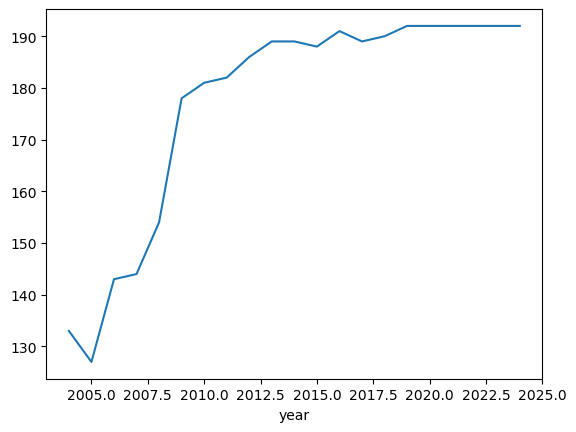

In [50]:
full_df.groupby('year').size().plot()

Plot turnover - does it look reasonable?

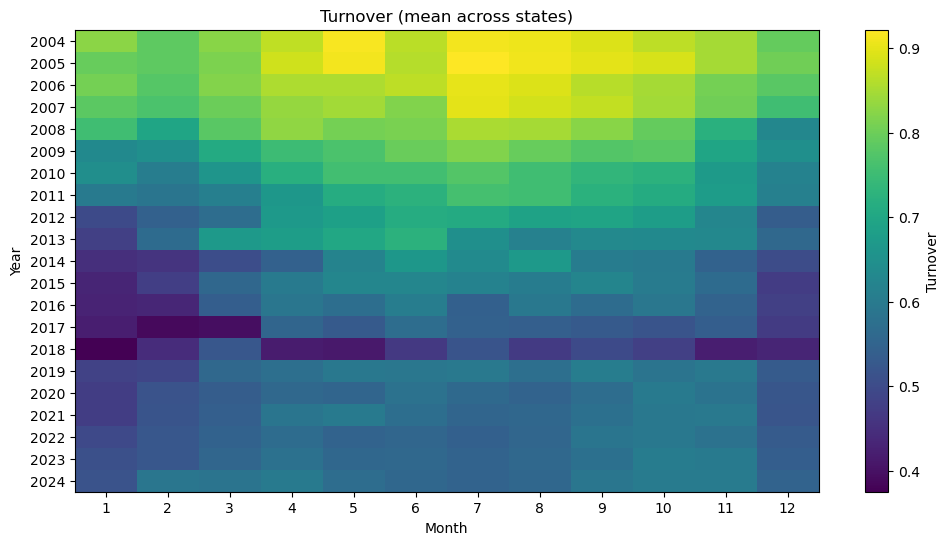

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

pivot = full_df.groupby(['year', 'month'])['turnover'].mean().unstack()

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Turnover')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(12), range(1,13))
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Turnover (mean across states)")
plt.show()

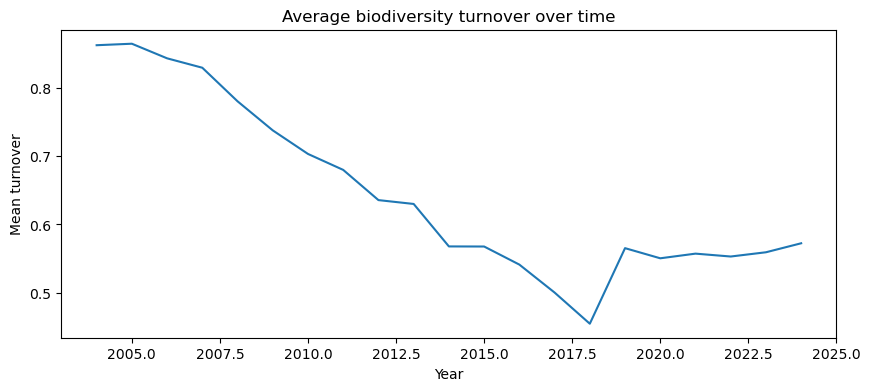

In [52]:
yearly = full_df.groupby('year')['turnover'].mean()

plt.figure(figsize=(10,4))
plt.plot(yearly.index, yearly.values)
plt.xlabel("Year")
plt.ylabel("Mean turnover")
plt.title("Average biodiversity turnover over time")
plt.show()

Create binary 'biodiversity anomaly' outcome feature for classification model

1. compute baseline for state and month

In [30]:
# import pandas as pd
# full_df = pd.read_parquet('../Data/Processed/full_df.parquet')

In [53]:
baseline = full_df.groupby(['state','month']).agg(
    mean_richness=('n_species','mean'),
    std_richness=('n_species','std')
).reset_index()

full_df = full_df.merge(baseline, on=['state','month'])

full_df.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,n_hot_days_roll6,drought_index_roll6,heavy_rain_days_roll6,n_obs,log_n_obs,n_species,jaccard,turnover,mean_richness,std_richness
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,2.333333,0.612179,0.833333,355.0,2.550228,93.0,0.178926,0.821074,231.428571,114.674135
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,2.000000,0.121404,1.333333,274.0,2.437751,108.0,0.202020,0.797980,276.900000,185.252005
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,0.000000,-0.483792,1.666667,815.0,2.911158,176.0,0.170146,0.829854,438.238095,290.009121
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,0.000000,-0.698102,1.666667,658.0,2.818226,197.0,0.111498,0.888502,743.523810,497.637581
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,0.000000,-0.067915,1.500000,914.0,2.960946,223.0,0.084793,0.915207,1135.380952,754.805039


2. Control for observation effort and year trend (with regression residuals)

In [32]:
# import statsmodels.api as sm

# X = sm.add_constant(full_df['log_n_obs']) # Creates dataframe of 1s (intercept) and log observations
# model = sm.OLS(full_df['n_species'], X).fit()

# full_df['expected_richness'] = model.predict(X)
# full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

In [54]:
# # per-state trends

import statsmodels.api as sm

# Create design matrix
X = pd.get_dummies(full_df['state'], drop_first=True)

X['log_n_obs'] = full_df['log_n_obs']
# X['year'] = full_df['year']
full_df['year_centered'] = full_df['year'] - full_df['year'].mean()
full_df['year_sq'] = full_df['year_centered'] ** 2
X['year_centered'] = full_df['year_centered']
X['year_sq'] = full_df['year_sq']

X = X.astype(float)

# Add intercept
X = sm.add_constant(X)

# Fit model (richness)
model = sm.OLS(full_df['n_species'], X).fit()

full_df['expected_richness'] = model.predict(X)
full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

# Fit model (turnover)
model = sm.OLS(full_df['turnover'], X).fit()

full_df['expected_turnover'] = model.predict(X)
full_df['residual_turnover'] = full_df['turnover'] - full_df['expected_turnover']

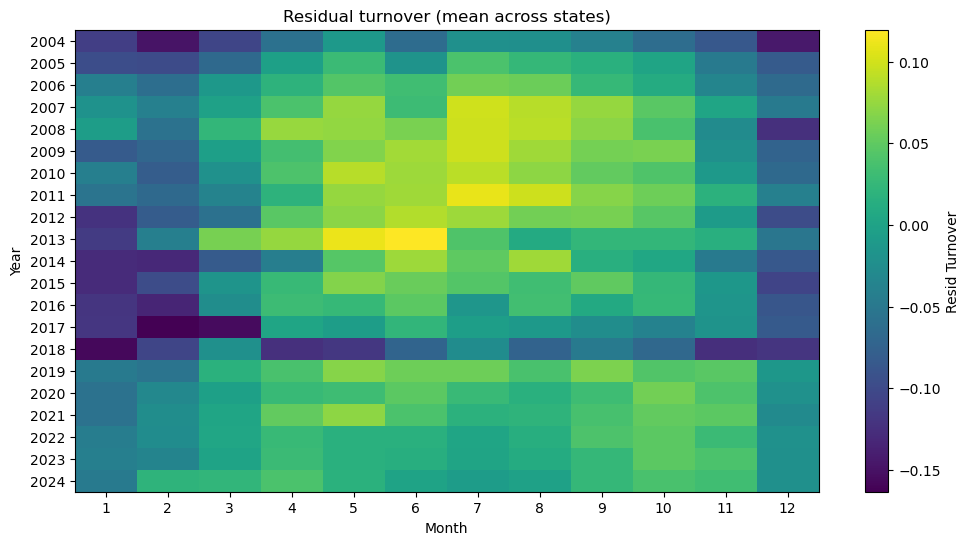

In [55]:
pivot = full_df.groupby(['year', 'month'])['residual_turnover'].mean().unstack()

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect='auto')
plt.colorbar(label='Resid Turnover')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.xticks(range(12), range(1,13))
plt.xlabel("Month")
plt.ylabel("Year")
plt.title("Residual turnover (mean across states)")
plt.show()

In [ ]:
# non-linear model

# import statsmodels.api as sm

# full_df['year_centered'] = full_df['year'] - full_df['year'].mean()
# full_df['year_sq'] = full_df['year_centered'] ** 2

# X = full_df[['log_n_obs', 'year_centered', 'year_sq']]
# X = sm.add_constant(X)

# model = sm.OLS(full_df['n_species'], X).fit()

# full_df['expected_richness'] = model.predict(X)
# full_df['residual'] = full_df['n_species'] - full_df['expected_richness']

In [32]:
import numpy as np
full_df['sp_per_obs'] = np.log(full_df['n_species']) - np.log(full_df['n_obs'])

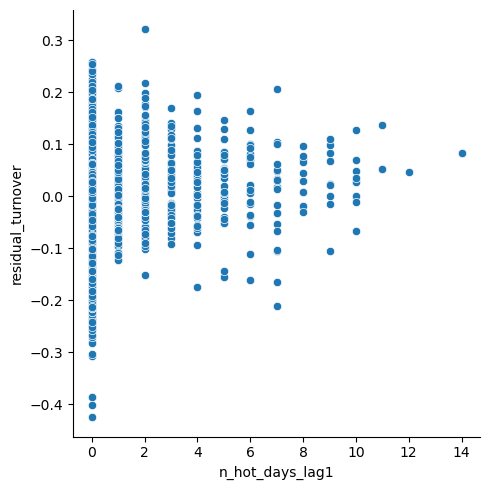

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.relplot(data = full_df,
            kind='scatter',
            x='n_hot_days_lag1',
            y='residual_turnover')
# plt.plot([0, 14], [0, -0.8], 'r-')
# plt.plot([0, 14], [1000, 100], 'r-')
plt.show();

3. Standardise residuals per state and month

In [61]:
full_df['residual_z'] = full_df.groupby(['state','month'])['residual'].transform(
    lambda x: (x - x.mean()) / x.std()
)

full_df['turnover_residual_z'] = full_df.groupby(['state','month'])['residual_turnover'].transform(
    lambda x: (x - x.mean()) / x.std()
)

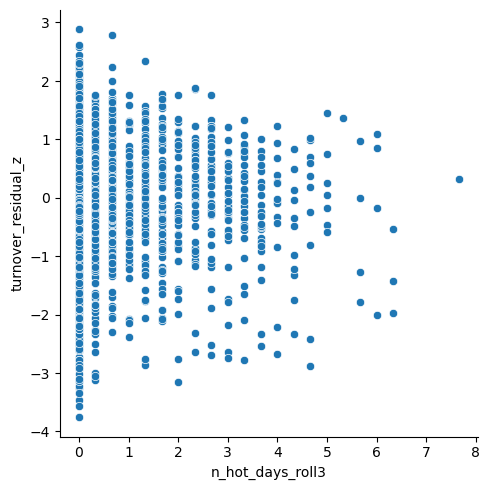

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.relplot(data = full_df,
            kind='scatter',
            x='n_hot_days_roll3',
            y='turnover_residual_z')
# plt.plot([0, 14], [0, -0.8], 'r-')
# plt.plot([0, 14], [1000, 100], 'r-')
plt.show();

4. Define binary anomaly  

interpretation:  
1 = biodiversity is unusually LOW for this state/month, given effort  
0 = normal or high biodiversity  

(or fine tune the threshold:  
-0.5 → more sensitive  
-1.0 → standard  
-1.5 → only extreme events
)

In [63]:
full_df['biodiversity_anomaly_standard'] = (full_df['residual_z'] < -1).astype(int)
full_df['biodiversity_anomaly_sensitive'] = (full_df['residual_z'] < -0.5).astype(int)
full_df['biodiversity_anomaly_conservative'] = (full_df['residual_z'] < -1.5).astype(int)

And for residual_turnover_z, higher values are 'bad':  

0 → expected turnover  
/>0 → higher-than-expected change  
< 0 → lower-than-expected change (more stable than expected)  

Use threshold based on quantiles in data - top 20% most extreme ecological change months

In [69]:
threshold = full_df['turnover_residual_z'].quantile(0.8)
full_df['high_turnover'] = (full_df['turnover_residual_z'] > 1.0).astype(int)

In [70]:
full_df.head()

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,expected_richness,residual,expected_turnover,residual_turnover,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,241.774393,-148.774393,0.952479,-0.131405,1.121782,-2.265966,0,0,0,0
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,192.272976,-84.272976,0.955461,-0.157481,1.401059,-2.212807,0,0,0,0
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,400.619172,-224.619172,0.942909,-0.113055,0.196204,-2.163934,0,0,0,0
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,359.719972,-162.719972,0.945373,-0.056872,-0.703810,-1.327739,0,1,0,0
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,422.531103,-199.531103,0.941589,-0.026382,-0.798810,-0.562096,0,1,0,0


In [50]:
full_df.value_counts('biodiversity_anomaly_standard')

biodiversity_anomaly_standard
0    3384
1     648
Name: count, dtype: int64

In [51]:
full_df.value_counts('biodiversity_anomaly_sensitive')

biodiversity_anomaly_sensitive
0    2752
1    1280
Name: count, dtype: int64

In [52]:
full_df.value_counts('biodiversity_anomaly_conservative')

biodiversity_anomaly_conservative
0    3803
1     229
Name: count, dtype: int64

In [71]:
full_df.value_counts('high_turnover')

high_turnover
0    3159
1     557
Name: count, dtype: int64

plot biodiversity residuals over time

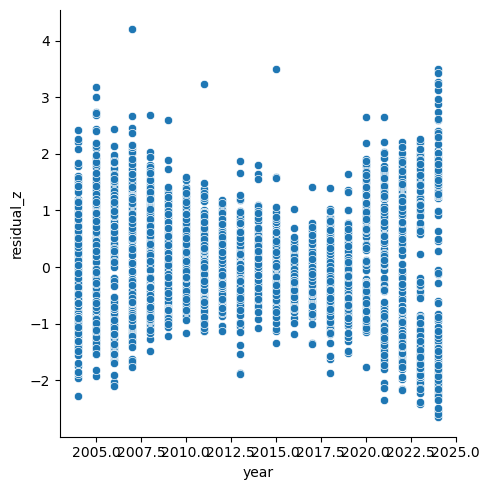

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.relplot(data = full_df,
            kind='scatter',
            x='year',
            y='residual_z')
plt.show();

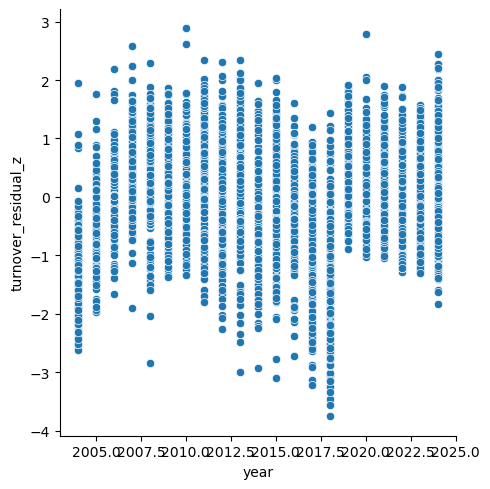

In [72]:
sns.relplot(data = full_df,
            kind='scatter',
            x='year',
            y='turnover_residual_z')
plt.show();

Double check that lagged variable calculations worked correctly

In [73]:
full_df.loc[full_df['state'].isin(['Bayern', 'Berlin'])][['state', 'monthyear', 'temp_anom_z', 'temp_anom_z_lag1']].groupby('state').head(3)

,state,monthyear,temp_anom_z,temp_anom_z_lag1
250,Bayern,1_2004,-0.484201,-0.255672
251,Bayern,2_2004,0.256806,-0.484201
252,Bayern,3_2004,-0.746567,0.256806
500,Berlin,1_2004,-0.731760,-0.016205
501,Berlin,2_2004,0.282089,-0.731760
502,Berlin,3_2004,0.109810,0.282089


Looks good - check if Jan lagged values are from December in previous year

In [74]:
(full_df.loc[(full_df['state'].isin(['Bayern', 'Berlin'])) 
            & (full_df['monthyear'].isin(['12_2004', '1_2005']))]
            [['state', 'monthyear', 'temp_anom_z', 'temp_anom_z_lag1']]
            .groupby('state')
            .head(3))

,state,monthyear,temp_anom_z,temp_anom_z_lag1
261,Bayern,12_2004,-0.890507,-0.991200
262,Bayern,1_2005,0.008640,-0.890507
511,Berlin,12_2004,-0.136432,-0.731508
512,Berlin,1_2005,0.646846,-0.136432


Looks good!

Circular encoding of months  
(so that December (12) and January (1) are not interpreted as 11 months apart from each other)  

What This Achieves  
1. Cyclic continuity:  
- December → January is smooth, not “jumping” from 12 → 1  
2. Numeric representation:  
- Each month gets two numeric features  
- Model can now learn patterns like “winter months” or “summer months” continuously  
3. Avoids artificial ordering:  
- Tree-based models or linear models now handle seasonality correctly  

In [75]:
from numpy import pi, sin, cos

full_df['month_sin'] = sin(2*pi * full_df['month'] / 12)
full_df['month_cos'] = cos(2*pi * full_df['month'] / 12)

Now re-base the year to 0

In [76]:
full_df['year_offset'] = full_df['year'] - min(full_df['year'])

In [77]:
full_df

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,residual_turnover,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover,month_sin,month_cos,year_offset
0,Baden-Württemberg,1_2004,2004,1,-0.184384,10.834500,133.100006,0,4,0.888582,...,-0.131405,1.121782,-2.265966,0,0,0,0,5.000000e-01,8.660254e-01,0
1,Baden-Württemberg,2_2004,2004,2,1.395922,14.384501,35.500000,0,2,1.658827,...,-0.157481,1.401059,-2.212807,0,0,0,0,8.660254e-01,5.000000e-01,0
2,Baden-Württemberg,3_2004,2004,3,3.290750,20.434500,39.500000,0,0,4.780743,...,-0.113055,0.196204,-2.163934,0,0,0,0,1.000000e+00,6.123234e-17,0
3,Baden-Württemberg,4_2004,2004,4,8.687417,21.584499,40.200001,0,1,9.264582,...,-0.056872,-0.703810,-1.327739,0,1,0,0,8.660254e-01,-5.000000e-01,0
4,Baden-Württemberg,5_2004,2004,5,11.212121,22.384499,71.699997,0,0,13.113695,...,-0.026382,-0.798810,-0.562096,0,1,0,0,5.000000e-01,-8.660254e-01,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3711,Thüringen,8_2024,2024,8,19.984138,30.950001,72.899994,2,2,18.361685,...,0.011573,-1.488965,-1.184104,1,1,0,0,-8.660254e-01,-5.000000e-01,20
3712,Thüringen,9_2024,2024,9,15.468820,30.500000,88.400002,1,2,14.538055,...,0.015630,-2.071312,-0.338740,1,1,1,0,-1.000000e+00,-1.836970e-16,20
3713,Thüringen,10_2024,2024,10,11.061694,18.700001,62.299999,0,1,10.015421,...,0.001136,-1.799099,-0.430616,1,1,1,0,-8.660254e-01,5.000000e-01,20
3714,Thüringen,11_2024,2024,11,4.483958,13.750000,53.499996,0,1,5.154050,...,0.026435,-1.646196,1.294947,1,1,1,1,-5.000000e-01,8.660254e-01,20


Save full_df - ready for model pipeline

In [78]:
full_df.to_parquet('../Data/Processed/full_df.parquet')

In [79]:
full_df.sample(10)

,state,monthyear,year,month,mean_temp,max_temp,total_precip,n_hot_days,heavy_rain_days,baseline_temp,...,residual_turnover,residual_z,turnover_residual_z,biodiversity_anomaly_standard,biodiversity_anomaly_sensitive,biodiversity_anomaly_conservative,high_turnover,month_sin,month_cos,year_offset
289,Bayern,6_2007,2007,6,17.728861,28.159000,102.400002,0,2,17.303177,...,-0.004641,-0.944452,0.264787,0,1,0,0,1.224647e-16,-1.000000e+00,3
2404,Rheinland-Pfalz,10_2005,2005,10,12.077363,19.594500,40.299999,0,2,10.230147,...,0.039976,0.799631,0.222687,0,0,0,0,-8.660254e-01,5.000000e-01,1
761,Brandenburg,8_2006,2006,8,17.589842,26.580500,70.199997,0,1,19.615812,...,0.067472,-0.871978,0.185579,0,1,0,0,-8.660254e-01,-5.000000e-01,2
48,Baden-Württemberg,3_2008,2008,3,3.468774,17.634499,105.099998,0,3,4.780743,...,0.067693,0.281765,0.803162,0,0,0,0,1.000000e+00,6.123234e-17,4
1697,Mecklenburg-Vorpommern,9_2009,2009,9,15.173722,27.609001,29.900000,0,0,14.862556,...,0.081471,0.164810,1.081276,0,0,0,1,-1.000000e+00,-1.836970e-16,5
1376,Hamburg,8_2024,2024,8,19.207527,30.350000,56.199997,1,2,18.217655,...,0.124737,-1.103424,0.309291,1,1,0,0,-8.660254e-01,-5.000000e-01,20
3311,Schleswig-Holstein,3_2009,2009,3,4.610175,10.317500,55.000000,0,1,4.232141,...,-0.048330,0.519619,-0.366516,0,0,0,0,1.000000e+00,6.123234e-17,5
3496,Schleswig-Holstein,8_2024,2024,8,17.989046,26.850000,63.400002,0,1,17.372301,...,0.004652,1.860318,-0.308804,0,0,0,0,-8.660254e-01,-5.000000e-01,20
1958,Niedersachsen,6_2010,2010,6,16.821543,28.463001,12.900000,0,0,17.184450,...,0.040705,-0.415061,0.714133,0,0,0,0,1.224647e-16,-1.000000e+00,6
742,Berlin,3_2024,2024,3,7.536895,21.700001,33.899998,0,0,4.696254,...,0.104886,-2.035885,1.823582,1,1,1,1,1.000000e+00,6.123234e-17,20
